In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as sts

In [2]:
url = "https://raw.githubusercontent.com/PedroGirotto/dataset_estatistica/refs/heads/main/aula01_intro/data.csv"
df = pd.read_csv(url)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [4]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
filtro = (df["math score"] > 80) 

dados = df[filtro]["parental level of education"].value_counts()
dados

parental level of education
associate's degree    54
some college          39
bachelor's degree     25
some high school      22
high school           19
master's degree       17
Name: count, dtype: int64

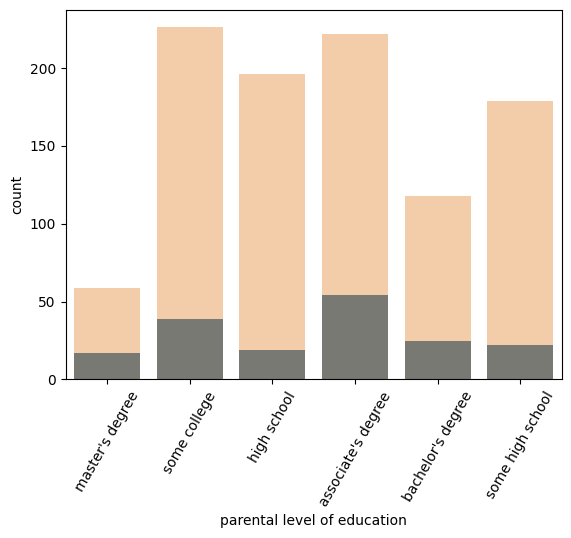

In [23]:
fig, ax = plt.subplots()
sns.countplot(data = df[filtro], x="parental level of education")
sns.countplot(data = df, x="parental level of education", alpha = 0.4)
plt.xticks(rotation=60)
plt.show()

In [30]:
df["mean"] = round((df["math score"] + df["reading score"] + df["writing score"])/3, 2)

In [31]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


<Axes: xlabel='mean', ylabel='Count'>

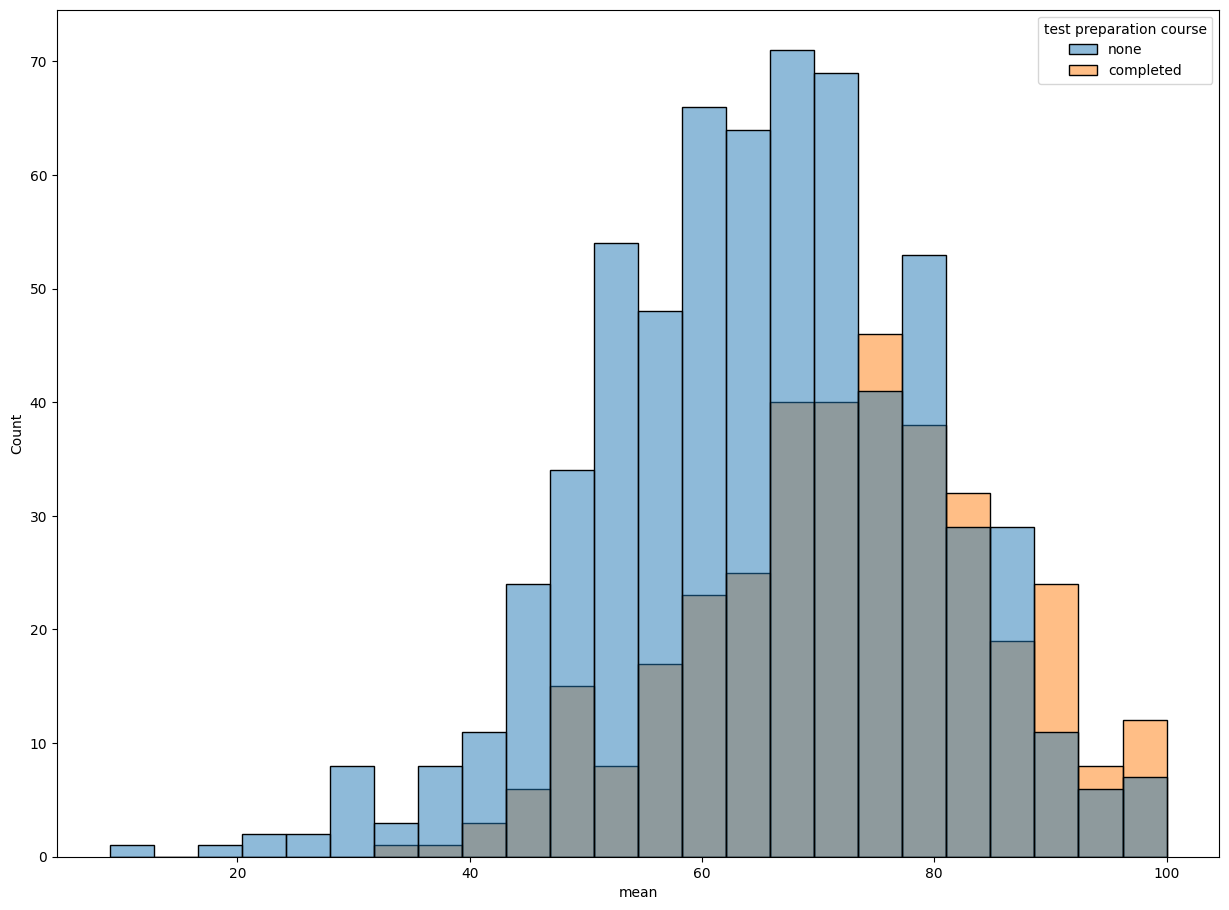

In [45]:
fig, axs = plt.subplots(figsize=(15,11))
sns.histplot(data = df, x="mean", hue="test preparation course")

In [49]:
sts.ttest_ind(df[df["test preparation course"] == "none"]["mean"],
              df[df["test preparation course"] == "completed"]["mean"])

TtestResult(statistic=np.float64(-8.391130002701122), pvalue=np.float64(1.631372979965714e-16), df=np.float64(998.0))

<Axes: xlabel='mean', ylabel='Count'>

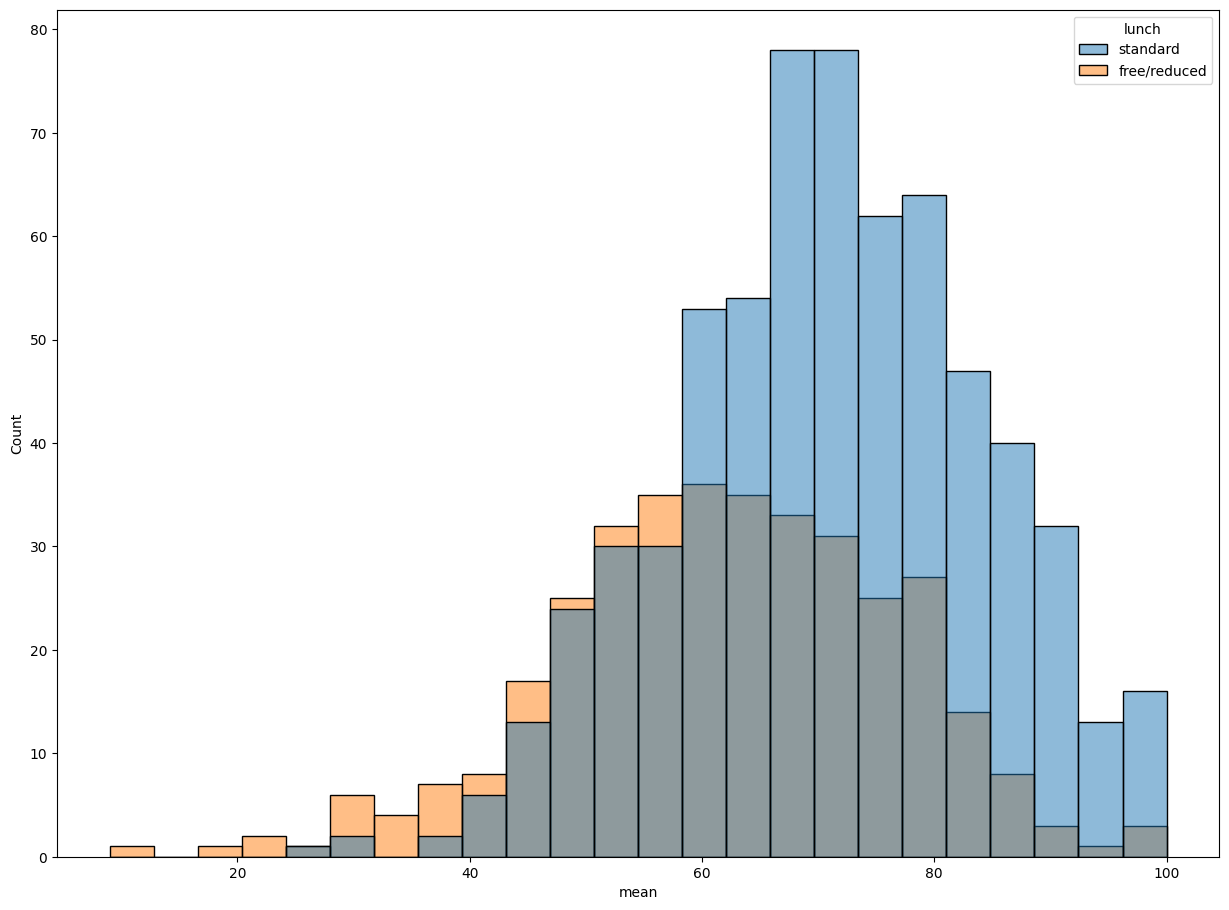

In [50]:
fig, axs = plt.subplots(figsize=(15,11))
sns.histplot(data = df, x="mean", hue="lunch")

<Axes: xlabel='mean', ylabel='Count'>

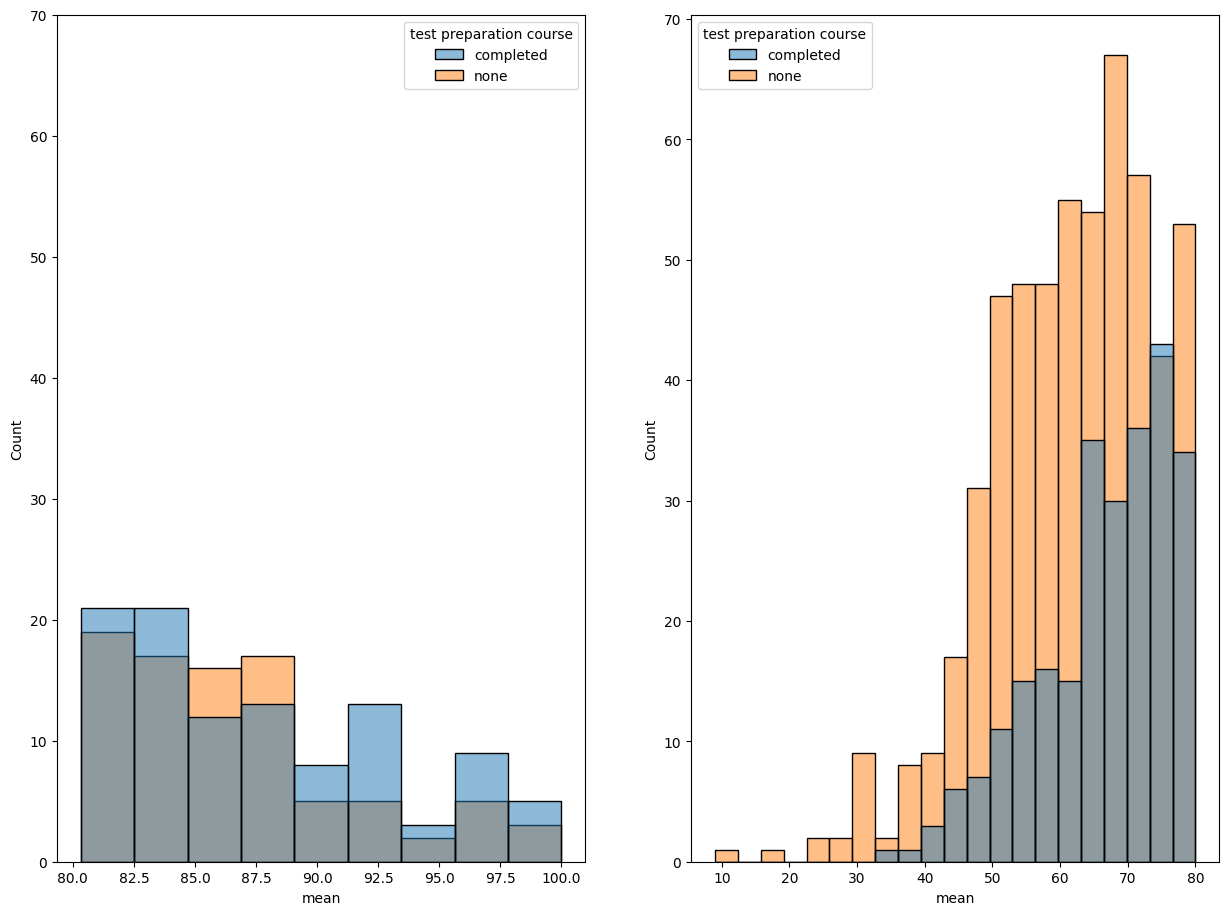

In [44]:
fig, axs = plt.subplots(figsize=(15,11), ncols=2)
sns.histplot(data = df[df["mean"] > 80], x="mean", hue="test preparation course", 
             ax=axs[0])
axs[0].set_ylim([0,70])
sns.histplot(data = df[df["mean"] <= 80], x="mean", hue="test preparation course", 
             hue_order=["completed", "none"], ax=axs[1])


In [51]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


In [55]:
df.groupby(["gender", "lunch"])["mean"].mean().reset_index()

,gender,lunch,mean
0,female,free/reduced,63.215185
1,female,standard,73.219848
2,male,free/reduced,61.041988
3,male,standard,68.356361
